# 03. 규칙 기반 평가 — 사이클 지표를 활용한 정상 내부 오경보율 측정

## 역할
`02_eda_segment_patterns.ipynb`에서 파형 유형을, `02_eda_segment_features.ipynb`에서
세그먼트별 RMS·전류 순수도·진동 균일성·자기상관과 길이 영향을 확인한다.
이 노트북은 해당 지표를 사용한 **규칙 기반 판정의 기준선 평가**를 담당한다.
정상 train의 극값 임계와 표준화 지표 평균의 결합 점수를 사용하며 이상탐지 모델 학습 단계는 아니다.

## 진행 과정
1. 모든 길이의 세그먼트에 동일한 정의로 지표를 계산한다.
2. 정상 데이터를 시간순 앞 70% / 뒤 30%로 나누고 앞부분에서만 기준을 정한다.
3. 개별 지표 임계와 결합 점수로 정상 test 오경보율 및 outlier 파일 기준 미탐률을 측정한다.
4. 오류 세그먼트의 지표와 원시 파형을 확인한다.
5. 마지막에 길이 구간별 오류율과 평가 가능한 건수를 비교한다.

라벨은 파일 단위이며 실제 세그먼트 정답이 아니다. 현재 평가로 조기탐지 성능이나
미탐의 원리적 한계를 확정하지 않는다. 과거 n≥10 실행 해석은 기록으로 구분한다.


## 0. 설정 및 로드

01·02와 동일한 정의를 그대로 가져온다(의도적으로 노트북마다 독립적으로 구성).

In [1]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# 현재 환경의 한글 폰트를 직접 등록한다 (기존 Matplotlib 캐시와 무관하게 적용).
for _font_path in [Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
                   Path("/mnt/c/Windows/Fonts/malgun.ttf")]:
    if _font_path.exists():
        font_manager.fontManager.addfont(str(_font_path))

_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]:
    if _f in _avail:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})

DATA_DIR = Path(os.environ.get("KAMP_DATA_DIR", "/mnt/d/data/kamp_ai/press_anomaly_dataset"))
FS, GAP_THR = 10.0, 0.15
MIN_N    = 1           # 짧은 세그먼트도 전부 포함해 길이별 오류율 평가
COLOR    = {"normal": "#1f77b4", "outlier": "#d62728"}

normal  = pd.read_csv(DATA_DIR / "press_data_normal.csv", index_col=0, parse_dates=["TimeStamp"])
outlier = pd.read_csv(DATA_DIR / "outlier_data.csv",      index_col=0, parse_dates=["TimeStamp"])
DFS = {"normal": normal, "outlier": outlier}

def make_segments(df):
    d = df["TimeStamp"].diff().dt.total_seconds()
    out = df.copy(); out["seg_id"] = (d > GAP_THR).cumsum().values
    return out

SEG = {k: make_segments(df) for k, df in DFS.items()}
print({k: len(v.seg_id.unique()) for k, v in SEG.items()}, "개 세그먼트")

{'normal': 599, 'outlier': 21} 개 세그먼트


## 1. 지표 함수 — 02 지표 EDA와 동일 정의

전류 `band_purity`는 정상 관측 주기대 0.9~2.2초의 지배 FFT 성분 비율이다.
탐색 성분이 없거나 에너지가 0이면 결측으로 처리한다.
`envelope_cv`는 10샘플 서브윈도우 RMS의 변동계수이며 n<20에서는 계산하지 않는다.


In [2]:
def band_purity(x, fs=FS, fmin=1/2.2, fmax=1/0.9):
    n = len(x); x = np.asarray(x, float) - np.mean(x)
    F = np.fft.rfft(x); freqs = np.fft.rfftfreq(n, d=1/fs)
    P = np.abs(F) ** 2
    band = (freqs >= fmin) & (freqs <= fmax)
    tot = P[1:].sum()
    return P[band].max() / tot if tot > 0 and band.any() else np.nan

def envelope_cv(x, win=10):
    # 1초(10샘플) 서브윈도우별 RMS의 변동계수. 서브윈도우가 2개 미만(n<20)이면 NaN
    x = np.asarray(x, float)
    n = len(x) // win
    if n < 2: return np.nan
    chunks = x[:n*win].reshape(n, win)
    sub_rms = np.sqrt((chunks ** 2).mean(axis=1))
    m = sub_rms.mean()
    return sub_rms.std() / m if m > 0 else np.nan

def build_features(sdf, label):
    rows = []
    for sid, g in sdf.groupby("seg_id"):
        if len(g) < MIN_N: continue
        x0, x2 = g["AI0_Vibration"].values, g["AI2_Current"].values
        rows.append({
            "label": label, "seg_id": sid, "n": len(g), "t_start": g.TimeStamp.iloc[0],
            "ai0_rms": float(np.sqrt((x0 ** 2).mean())),
            "ai0_ac1": float(pd.Series(x0).autocorr(1)) if len(g) > 3 else np.nan,
            "purity":  band_purity(x2),
            "env_cv":  envelope_cv(x0),
        })
    return pd.DataFrame(rows)

F  = pd.concat([build_features(SEG[k], k) for k in DFS], ignore_index=True)
Fn = F[F.label == "normal"].sort_values("t_start").reset_index(drop=True)
Fo = F[F.label == "outlier"].sort_values("t_start").reset_index(drop=True)

print(f"normal {len(Fn)}개 (env_cv 결측 {Fn.env_cv.isna().sum()}개)")
print(f"outlier {len(Fo)}개 (env_cv 결측 {Fo.env_cv.isna().sum()}개: "
      f"seg {Fo.loc[Fo.env_cv.isna(),'seg_id'].tolist()})")
display(Fn[["ai0_rms","ai0_ac1","purity","env_cv"]].describe().round(4))

normal 599개 (env_cv 결측 147개)
outlier 21개 (env_cv 결측 8개: seg [0, 4, 5, 9, 10, 14, 19, 20])


,ai0_rms,ai0_ac1,purity,env_cv
count,599.0000,575.0000,538.0000,452.0000
mean,0.0672,-0.0390,0.8589,0.1735
std,0.0230,0.3208,0.1966,0.0876
min,0.0029,-0.9935,0.1496,0.0004
25%,0.0477,-0.3138,0.7911,0.1067
50%,0.0694,-0.0408,0.9684,0.1709
75%,0.0840,0.2104,0.9954,0.2353
max,0.1530,0.9995,0.9996,0.5305


## 2. 정상 내부 오경보율 측정 (최우선 과제)

의도: normal을 시간순으로 앞 70% / 뒤 30%로 쪼갠다. **앞부분만으로 기준(임계값)을 정하고,
뒷부분(정상인데 모델은 본 적 없는 데이터)에 그대로 적용**했을 때 오경보가 몇 개나 나는지
잰다. 뒤 30%에는 02에서 찾은 V자 드리프트 구간(01:00~01:17)이 통째로 들어있어서, "정상의
자연스러운 운전조건 변화 때문에 오경보가 느는가"를 가장 가혹한 조건에서 시험하는 셈이다.

In [3]:
split = Fn.t_start.quantile(0.70)
train, test = Fn[Fn.t_start < split].copy(), Fn[Fn.t_start >= split].copy()
dip_in_test = (test.t_start >= pd.Timestamp("2022-07-12 01:00:00")).sum()

print(f"train(앞 70%) {len(train)}개  [{train.t_start.min()} ~ {train.t_start.max()}]")
print(f"test (뒤 30%) {len(test)}개  [{test.t_start.min()} ~ {test.t_start.max()}]")
print(f"  -> test 안에 V자 딥 구간(01:00~) 세그먼트 {dip_in_test}개 포함"
      f" ({dip_in_test/len(test)*100:.0f}%) — 가장 가혹한 조건")

train(앞 70%) 419개  [2022-07-12 00:00:00.019000 ~ 2022-07-12 00:52:39.609000]
test (뒤 30%) 180개  [2022-07-12 00:52:47.696000 ~ 2022-07-12 01:16:51.528000]
  -> test 안에 V자 딥 구간(01:00~) 세그먼트 126개 포함 (70%) — 가장 가혹한 조건


In [4]:
FEATS = {"ai0_rms": ">", "purity": "<", "env_cv": ">", "ai0_ac1": ">"}

rows = []
for f, direction in FEATS.items():
    thr = train[f].max() if direction == ">" else train[f].min()
    fa  = (test[f] > thr).sum() if direction == ">" else (test[f] < thr).sum()
    valid = test[f].notna().sum()
    rows.append({"피처": f, "방향": direction, "train 임계(FP=0)": round(thr, 4),
                 "test 오경보": f"{fa}/{valid}", "오경보율": round(fa/valid*100, 2) if valid else np.nan})
display(pd.DataFrame(rows).set_index("피처"))

,방향,train 임계(FP=0),test 오경보,오경보율
피처,,,,
ai0_rms,>,0.1530,0/180,0.00
purity,<,0.1578,1/165,0.61
env_cv,>,0.5305,0/139,0.00
ai0_ac1,>,0.6982,1/178,0.56


> **이하 내용은 기존 n≥10 실행의 기록입니다.** 전체 길이 포함 결과는 위 코드의 재실행 출력과 마지막 길이별 평가를 기준으로 읽습니다. 기존 미탐지를 원리적 한계로 확정하지 않습니다.

**결과:** 개별 피처 전부 **오경보율 0~0.6%**다. V자 딥 구간(진폭이 40% 가까이 줄어드는
구간)을 통째로 포함한 test셋인데도 거의 오경보가 나지 않는다 — 이유는 딥 구간이 신호를
"더 작고 조용하게" 만들 뿐이라, `ai0_rms`·`env_cv`처럼 "크면 이상"으로 보는 피처 입장에서는
오히려 더 안전한 쪽으로 움직이기 때문이다(02에서 확인한 대로 딥 구간도 같은 파형·같은
주기가 유지되고 진폭만 준다 — 파형이 깨지는 게 아니다). **01_eda·02에서 우려했던
"정상 드리프트로 인한 오경보"는 적어도 이번 데이터·이 피처들에서는 기우였다.**

### 2-1. 오탐 1건 — 원시 파형 및 정상과의 비교

의도: 유일한 오탐(seg488)이 숫자로는 purity 임계를 살짝 넘었는데, 실제 파형도 눈으로
봤을 때 이상해 보이는지 전형적인 normal 두 개와 나란히 놓고 확인한다.

오탐 세그먼트:


,seg_id,n,t_start,ai0_rms,purity,env_cv
488,488,23,2022-07-12 01:02:00.218,0.032984,0.149611,0.046029


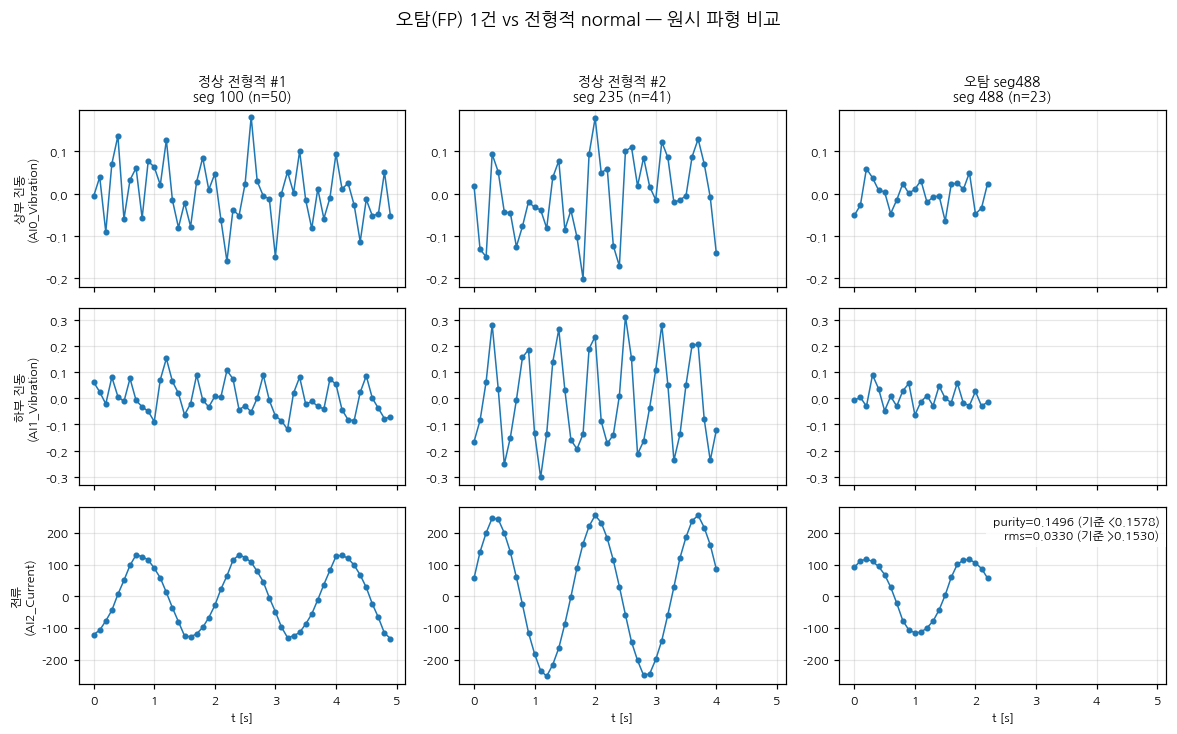

In [5]:
rms_thr, pur_thr, env_thr = train.ai0_rms.max(), train.purity.min(), train.env_cv.max()
fp = test.loc[(test.ai0_rms > rms_thr) | (test.purity < pur_thr) | (test.env_cv.fillna(0) > env_thr)]
print("오탐 세그먼트:")
display(fp[["seg_id", "n", "t_start", "ai0_rms", "purity", "env_cv"]])

raw_channels = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
raw_names = ["상부 진동", "하부 진동", "전류"]
fp_sid = int(fp.seg_id.iloc[0]) if len(fp) else int(test.nsmallest(1, "purity").seg_id.iloc[0])
picks = [("정상 전형적 #1", "normal", 100), ("정상 전형적 #2", "normal", 235),
         (f"오탐 seg{fp_sid}", "normal", fp_sid)]

fig, axes = plt.subplots(3, len(picks), figsize=(3.6*len(picks), 6.5), sharex=True)
for j, (label, k, sid) in enumerate(picks):
    g = SEG[k][SEG[k].seg_id == sid]
    t = np.arange(len(g)) / FS
    for i, (ch, name) in enumerate(zip(raw_channels, raw_names)):
        axes[i, j].plot(t, g[ch], "o-", color=COLOR[k], lw=1, ms=3)
        if j == 0: axes[i, j].set_ylabel(f"{name}\n({ch})", fontsize=8)
    axes[0, j].set_title(f"{label}\nseg {sid} (n={len(g)})", fontsize=9)
    axes[-1, j].set_xlabel("t [s]", fontsize=8)
for i in range(3):
    lo = min(ax.get_ylim()[0] for ax in axes[i]); hi = max(ax.get_ylim()[1] for ax in axes[i])
    for ax in axes[i]: ax.set_ylim(lo, hi)

r = Fn.loc[Fn.seg_id == fp_sid].iloc[0]
axes[2, -1].text(.98, .95,
                  f"purity={r.purity:.4f} (기준 <{pur_thr:.4f})\n"
                  f"rms={r.ai0_rms:.4f} (기준 >{rms_thr:.4f})",
                  transform=axes[2, -1].transAxes, ha="right", va="top", fontsize=8,
                  bbox=dict(facecolor="white", alpha=.85, edgecolor="none"))
fig.suptitle("오탐(FP) 1건 vs 전형적 normal — 원시 파형 비교", y=1.02)
plt.tight_layout(); plt.show()

> **이하 내용은 기존 n≥10 실행의 기록입니다.** 전체 길이 포함 결과는 위 코드의 재실행 출력과 마지막 길이별 평가를 기준으로 읽습니다. 기존 미탐지를 원리적 한계로 확정하지 않습니다.

**결과:** seg488의 전류 파형은 **눈으로 봐도 normal과 거의 구분이 안 될 만큼 매끈한
사인 모양**이다. 다만 세그먼트가 짧아(n=23, 2.3초) 완전한 1주기를 다 못 채운 채 끝나서,
`band_purity` 계산상 분모(전체 에너지) 대비 분자(지배주파수 에너지) 비율이 normal의 긴
세그먼트들보다 살짝 불리하게 나온다 — **purity 0.1496 vs 임계 0.1578, 차이가 0.008뿐이다.**
즉 이 오탐은 신호가 진짜로 이상해서가 아니라 **짧은 세그먼트의 경계선 수치 차이**다.
seg19·20(미탐)에서 본 "짧은 세그먼트는 지표가 불안정하다"는 문제가 오탐 쪽에서도 똑같이
나타난 셈 — **세그먼트 길이가 짧을 때 양방향(미탐·오탐) 모두에 영향을 준다**는 게
이번에 새로 확인된 패턴이다.

### 2-2. 오탐에 가까운 케이스 — 실제 오탐(seg488)과 비교

의도: seg488 하나만으로는 "짧은 세그먼트라 우연히 그런가"를 판단하기 어렵다. purity
임계에 가장 가깝게 접근한(하지만 넘지는 않은) normal 세그먼트들을 찾아 seg488과 나란히
놓고, 공통점이 있는지 확인한다.

purity 기준 '오탐에 가장 가까운' normal 3개 (경보는 안 울렸지만 임계에 근접):


,seg_id,n,t_start,ai0_rms,purity,env_cv
307,307,23,2022-07-12 00:38:53.456,0.079401,0.157829,0.027918
110,110,23,2022-07-12 00:13:55.976,0.065224,0.169857,0.011046
420,420,23,2022-07-12 00:52:55.616,0.080153,0.181167,0.298765


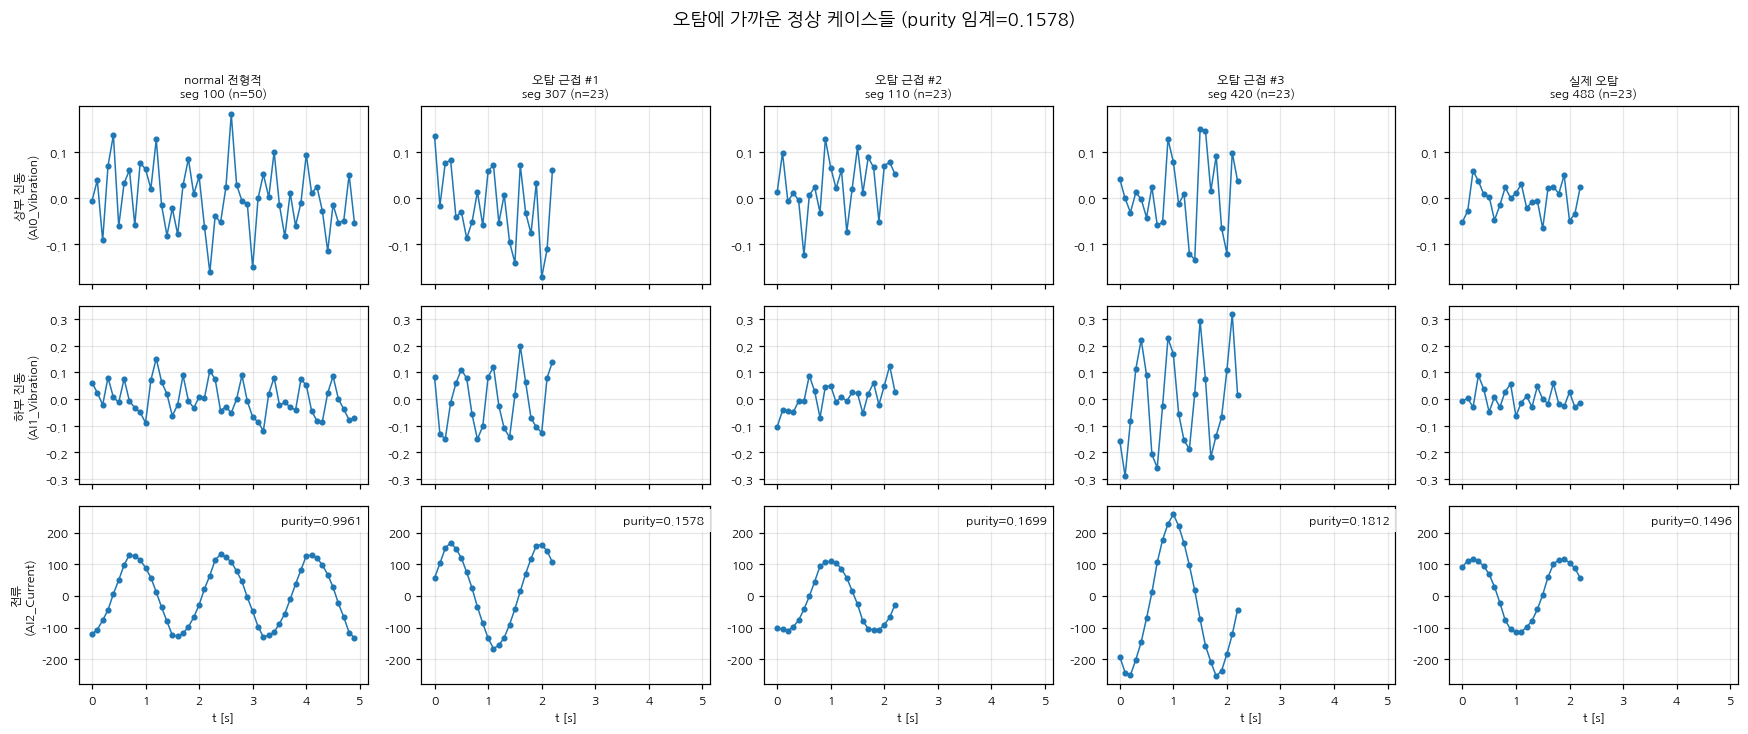

In [6]:
near_pur = Fn[(Fn.purity >= pur_thr) & (Fn.seg_id != fp_sid)].nsmallest(3, "purity")
print("purity 기준 '오탐에 가장 가까운' normal 3개 (경보는 안 울렸지만 임계에 근접):")
display(near_pur[["seg_id", "n", "t_start", "ai0_rms", "purity", "env_cv"]])

picks_near = [("normal 전형적", "normal", 100)] + \
             [(f"오탐 근접 #{i+1}", "normal", sid) for i, sid in enumerate(near_pur.seg_id)] + \
             [("실제 오탐", "normal", fp_sid)]

fig, axes = plt.subplots(3, len(picks_near), figsize=(3.2*len(picks_near), 6.5), sharex=True)
for j, (label, k, sid) in enumerate(picks_near):
    g = SEG[k][SEG[k].seg_id == sid]
    t = np.arange(len(g)) / FS
    for i, (ch, name) in enumerate(zip(raw_channels, raw_names)):
        axes[i, j].plot(t, g[ch], "o-", color=COLOR[k], lw=1, ms=3)
        if j == 0: axes[i, j].set_ylabel(f"{name}\n({ch})", fontsize=8)
    axes[0, j].set_title(f"{label}\nseg {sid} (n={len(g)})", fontsize=8)
    axes[-1, j].set_xlabel("t [s]", fontsize=8)
    pur = Fn.loc[Fn.seg_id == sid, "purity"].iloc[0]
    axes[2, j].text(.98, .95, f"purity={pur:.4f}", transform=axes[2, j].transAxes,
                     ha="right", va="top", fontsize=8, bbox=dict(facecolor="white", alpha=.85, edgecolor="none"))
for i in range(3):
    lo = min(ax.get_ylim()[0] for ax in axes[i]); hi = max(ax.get_ylim()[1] for ax in axes[i])
    for ax in axes[i]: ax.set_ylim(lo, hi)
fig.suptitle(f"오탐에 가까운 정상 케이스들 (purity 임계={pur_thr:.4f})", y=1.02)
plt.tight_layout(); plt.show()

> **이하 내용은 기존 n≥10 실행의 기록입니다.** 전체 길이 포함 결과는 위 코드의 재실행 출력과 마지막 길이별 평가를 기준으로 읽습니다. 기존 미탐지를 원리적 한계로 확정하지 않습니다.

**결과:** purity가 임계에 가장 가까운 normal 3개(seg307·110·420)와 실제 오탐(seg488)
**전부 `n=23`이다** — 우연이 아니다. 전형적 normal(seg100, n=50)의 purity는 0.996인데
이 넷은 0.15~0.18로 훨씬 낮다. 그런데 파형을 눈으로 보면 넷 다 **멀쩡한 사인 곡선**이다
(완전히 반듯하진 않지만 전형적 normal과 비교해 두드러지게 이상하지 않다).

→ **오탐 위험은 특정 신호 이상이 아니라 특정 세그먼트 길이(n≈23)에서 구조적으로
몰려 있다.** 02에서 "길이가 짧으면 purity·R² 추정이 불안정해진다"고 본 것과 정확히
같은 현상이 오탐 쪽에서도 재현된다 — 미탐지(seg19·20, n=10·15)와 오탐(seg488 등,
n=23) 둘 다 "세그먼트가 짧다"는 공통 조건에서 나온다. 로직을 바꾸진 않았지만, 04에서
"n이 특정 범위일 때 purity 임계를 조정하거나 가중치를 낮춘다" 같은 길이 보정을
검토할 근거가 된다.

## 3. 결합 점수 설계

의도: 세 피처(진폭·전류순수도·균일성)를 하나의 이상도 점수로 합친다. 서로 스케일이 달라
train 기준으로 z-score화한 뒤 평균한다. `env_cv`가 결측인 짧은 세그먼트(n<20)는 있는
피처만으로 평균 내도록 `nanmean`을 쓴다 — 세그먼트가 짧다는 이유로 통째로 버리지 않는다.

In [7]:
def z(s, ref):
    std = ref.std()
    return (s - ref.mean()) / std if pd.notna(std) and std > 0 else s * np.nan

def combo_score(df, ref):
    parts = [z(df.ai0_rms, ref.ai0_rms), -z(df.purity, ref.purity), z(df.env_cv, ref.env_cv)]
    M = np.vstack([p.values for p in parts])
    return np.nanmean(M, axis=0)

train["score"] = combo_score(train, train)
test["score"]  = combo_score(test,  train)
Fo["score"]    = combo_score(Fo,    train)
Fn["score"]    = combo_score(Fn,    train)

thr_combo = train.score.max()
fa_combo  = (test.score > thr_combo).sum()
print(f"결합점수 train 임계(FP=0) = {thr_combo:.3f}")
print(f"test 오경보: {fa_combo}/{len(test)} ({fa_combo/len(test)*100:.1f}%)")

det = Fo.score > thr_combo
print(f"\noutlier 탐지: {det.sum()}/{len(Fo)}  미탐지 seg: {Fo.loc[~det,'seg_id'].tolist()}")
display(Fo[["seg_id","n","t_start","ai0_rms","purity","env_cv","score"]].round(4))

결합점수 train 임계(FP=0) = 3.942
test 오경보: 0/180 (0.0%)

outlier 탐지: 18/21  미탐지 seg: [3, 19, 20]


,seg_id,n,t_start,ai0_rms,purity,env_cv,score
0,0,4,2022-07-17 10:51:07.943,0.7268,NaN,NaN,31.8291
1,1,50,2022-07-17 10:51:16.724,0.3913,0.0692,0.6447,8.2565
2,2,47,2022-07-17 10:51:23.615,0.5152,0.0563,0.4911,9.7173
3,3,31,2022-07-17 10:51:31.734,0.0458,0.0671,0.3715,1.6522
4,4,18,2022-07-17 10:51:39.999,0.6992,0.3245,NaN,16.6476
5,5,3,2022-07-17 10:51:48.093,0.9644,NaN,NaN,43.3726
6,6,50,2022-07-17 10:51:56.684,0.5597,0.1373,0.7099,11.1080
7,7,40,2022-07-17 10:52:04.407,0.3374,0.1749,0.7681,7.6589
8,8,25,2022-07-17 10:52:12.567,0.3314,0.2021,0.6555,7.0964
9,9,8,2022-07-17 10:52:21.018,0.4689,NaN,NaN,19.2931


> **이하 내용은 기존 n≥10 실행의 기록입니다.** 전체 길이 포함 결과는 위 코드의 재실행 출력과 마지막 길이별 평가를 기준으로 읽습니다. 기존 미탐지를 원리적 한계로 확정하지 않습니다.

**결과:** 결합 점수도 **test 오경보 0%**를 유지하면서, outlier **17개 중 14개**를 잡는다.
미탐지는 여전히 **seg 3·19·20** — 01_eda(임계값 미탐지)·02(tier 분류) 두 가지 독립적
방법에서 이미 나온 것과 **정확히 같은 세 개**다. 세 번째 독립적 접근(결합 점수)에서도
동일하게 재현된다는 건, 이 셋이 우연이 아니라 **이 신호로는 원리적으로 못 잡는
하한**이라는 뜻이다(이 셋은 진폭·전류·균일성 전부 정상 범위 안에 있다 — 01_eda 5번
교락 문제와 관련해 "정말 이상인지"조차 재고할 여지가 있다).

### 3-1. 미탐지 세그먼트의 피처 시계열

의도: 미탐지 seg 3·19·20이 주변 이상 세그먼트와 어떻게 다른지, outlier 전체의 시간 흐름에서
확인한다. 세 결합 피처(`ai0_rms`, `purity`, `env_cv`)와 보조 `ai0_ac1`, 결합 점수를
같은 시간축에 놓고 **미탐지는 주황색**, 정상 학습 구간의 최솟값~최댓값은 회색 띠로 표시한다.
점선은 개별 피처의 정상 학습 극값 기준이며, 실제 미탐지 여부는 마지막 패널의 결합 점수로 정한다.

각 점은 세그먼트 전체에서 계산한 값이며 x축은 세그먼트 시작 시각이다.
세그먼트 사이 선은 흐름을 보기 위한 연결선으로, gap 구간의 신호를 보간한 것은 아니다.
`env_cv`가 없는 짧은 세그먼트는 값을 채우지 않고 축 아래에 결측으로 표시한다.


,seg_id,n,t_start,ai0_rms,purity,env_cv,ai0_ac1,score
3,3,31,2022-07-17 10:51:31.734,0.0458,0.0671,0.3715,0.0614,1.6522
19,19,10,2022-07-17 10:53:42.668,0.0321,0.3999,NaN,0.5906,0.2430
20,20,15,2022-07-17 10:53:52.140,0.0433,0.0066,NaN,0.3747,1.5343


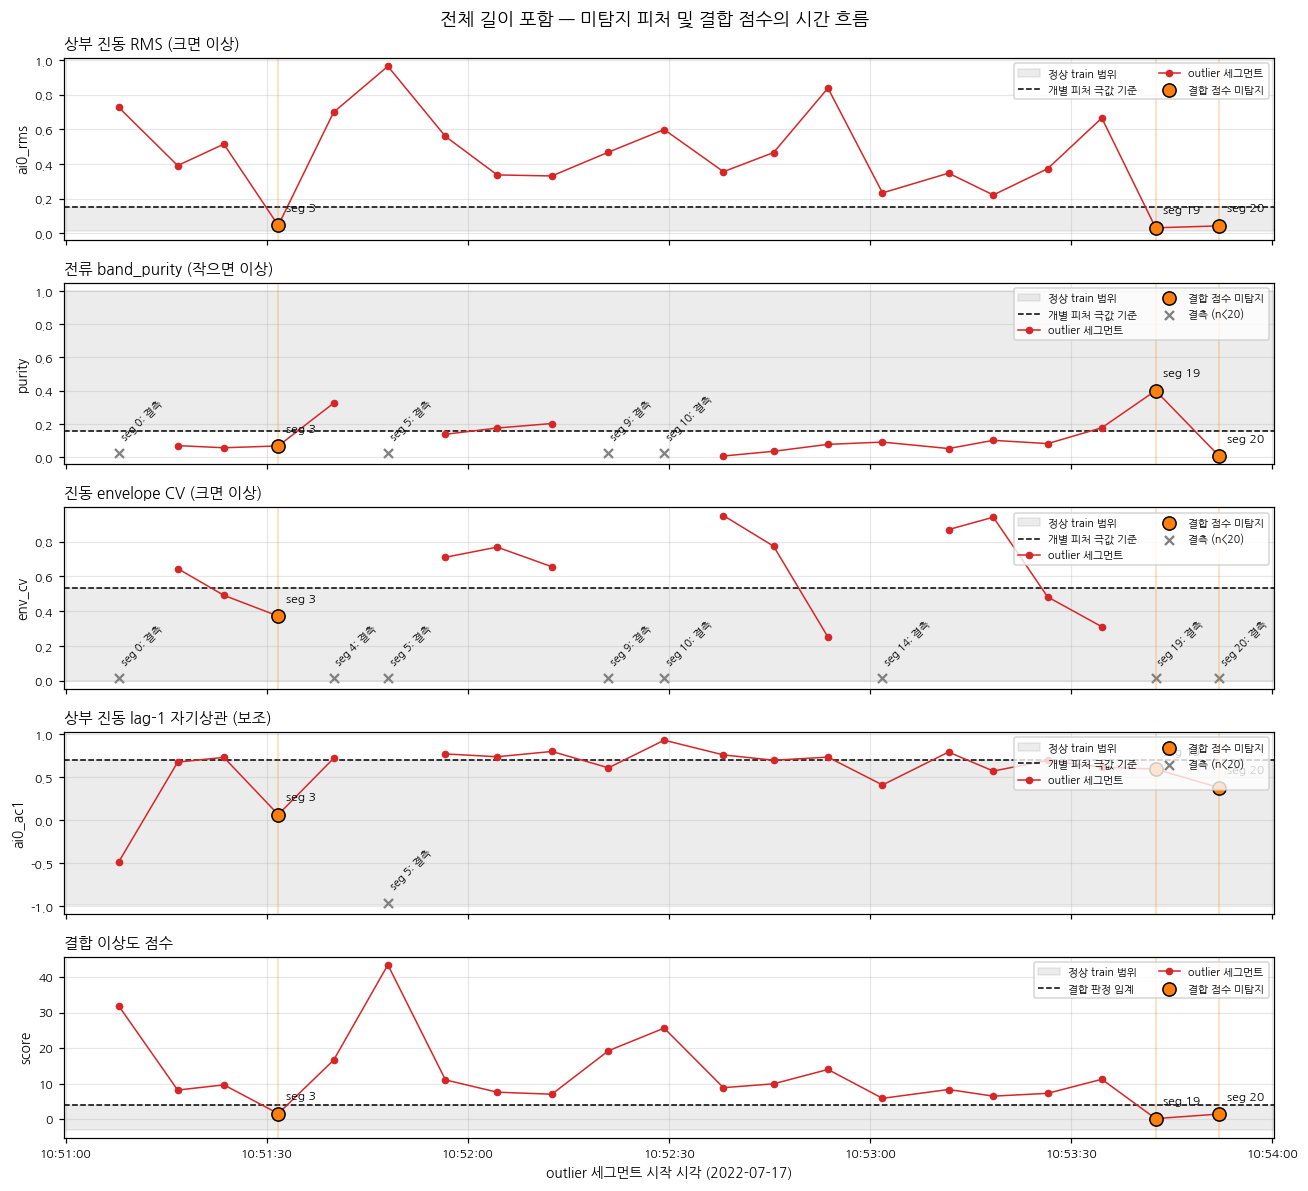

In [8]:
import matplotlib.dates as mdates

miss_mask = Fo["score"] <= thr_combo
miss_features = Fo.loc[miss_mask, ["seg_id", "n", "t_start", "ai0_rms", "purity",
                                   "env_cv", "ai0_ac1", "score"]]
display(miss_features.round(4))

panels = [("ai0_rms", "상부 진동 RMS (크면 이상)", ">"),
          ("purity", "전류 band_purity (작으면 이상)", "<"),
          ("env_cv", "진동 envelope CV (크면 이상)", ">"),
          ("ai0_ac1", "상부 진동 lag-1 자기상관 (보조)", ">"),
          ("score", "결합 이상도 점수", ">")]
fig, axes = plt.subplots(len(panels), 1, figsize=(12, 11), sharex=True)
for ax, (feat, title, direction) in zip(axes, panels):
    ref = train[feat].dropna()
    threshold = thr_combo if feat == "score" else (ref.max() if direction == ">" else ref.min())
    ax.axhspan(ref.min(), ref.max(), color="gray", alpha=.15, label="정상 train 범위")
    ax.axhline(threshold, color="black", ls="--", lw=1,
               label="결합 판정 임계" if feat == "score" else "개별 피처 극값 기준")
    ax.plot(Fo.t_start, Fo[feat], "o-", color=COLOR["outlier"], ms=4, lw=1,
            label="outlier 세그먼트")
    valid_miss = miss_mask & Fo[feat].notna()
    ax.scatter(Fo.loc[valid_miss, "t_start"], Fo.loc[valid_miss, feat],
               s=75, color="#ff7f0e", edgecolor="black", zorder=5, label="결합 점수 미탐지")
    for row in Fo.loc[miss_mask].itertuples():
        ax.axvline(row.t_start, color="#ff7f0e", alpha=.3, lw=1)
        value = getattr(row, feat)
        if pd.notna(value):
            ax.annotate(f"seg {row.seg_id}", (row.t_start, value), xytext=(5, 9),
                        textcoords="offset points", fontsize=8)
    missing = Fo[feat].isna()
    if missing.any():
        ax.scatter(Fo.loc[missing, "t_start"], np.full(missing.sum(), .06),
                   transform=ax.get_xaxis_transform(), marker="x", color="gray", s=35,
                   label="결측 (n<20)")
        for row in Fo.loc[missing].itertuples():
            ax.text(row.t_start, .13, f"seg {row.seg_id}: 결측", rotation=45, fontsize=7,
                    transform=ax.get_xaxis_transform(), ha="left")
    ax.set_title(title, loc="left")
    ax.set_ylabel(feat)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
axes[-1].set_xlabel("outlier 세그먼트 시작 시각 (2022-07-17)")
fig.suptitle("전체 길이 포함 — 미탐지 피처 및 결합 점수의 시간 흐름", fontsize=12)
plt.tight_layout(); plt.show()


> **이하 내용은 기존 n≥10 실행의 기록입니다.** 전체 길이 포함 결과는 위 코드의 재실행 출력과 마지막 길이별 평가를 기준으로 읽습니다. 기존 미탐지를 원리적 한계로 확정하지 않습니다.

**읽는 법:** seg 3은 낮은 전류 순수도와 높은 `env_cv`가 보여도 진동 RMS가 낮아,
평균한 결합 점수는 임계 아래에 남는다. seg 19·20은 `n=10·15`로 짧아 `env_cv`가 결측이고,
진동 RMS와 전류 순수도 두 피처만으로 점수를 낸다. 특히 seg 20도 전류 순수도는 낮지만
결합 점수는 임계를 넘지 못한다.

따라서 이 그림은 **현재 결합 방식과 임계에서 미탐지된 이유**를 살펴보는 자료다.
세 피처가 모두 정상처럼 보이거나 다른 판정 방식으로도 탐지가 불가능하다는 뜻은 아니다.


### 3-2. 미탐지 seg 3·19·20 — 원시 파형

의도: 각 미탐지 세그먼트의 상부 진동·하부 진동·전류 원시 파형을 별도 그림으로 확인한다.
x축은 실제 timestamp 기준의 세그먼트 내 경과시간이며, 점은 관측 샘플이다.
같은 채널은 세 그림에서 y축 범위를 통일한다.

상부 진동의 ±RMS 임계선은 **진폭 참고선**이다. RMS는 세그먼트 전체 통계이므로,
개별 샘플이 선을 넘었다고 이상으로 판정하지 않는다. purity·env CV는 원시값과 단위가 달라
수치로 비교한다. 최종 판정 기준은 결합 점수가 정상 학습 최대 점수를 초과하는지다.


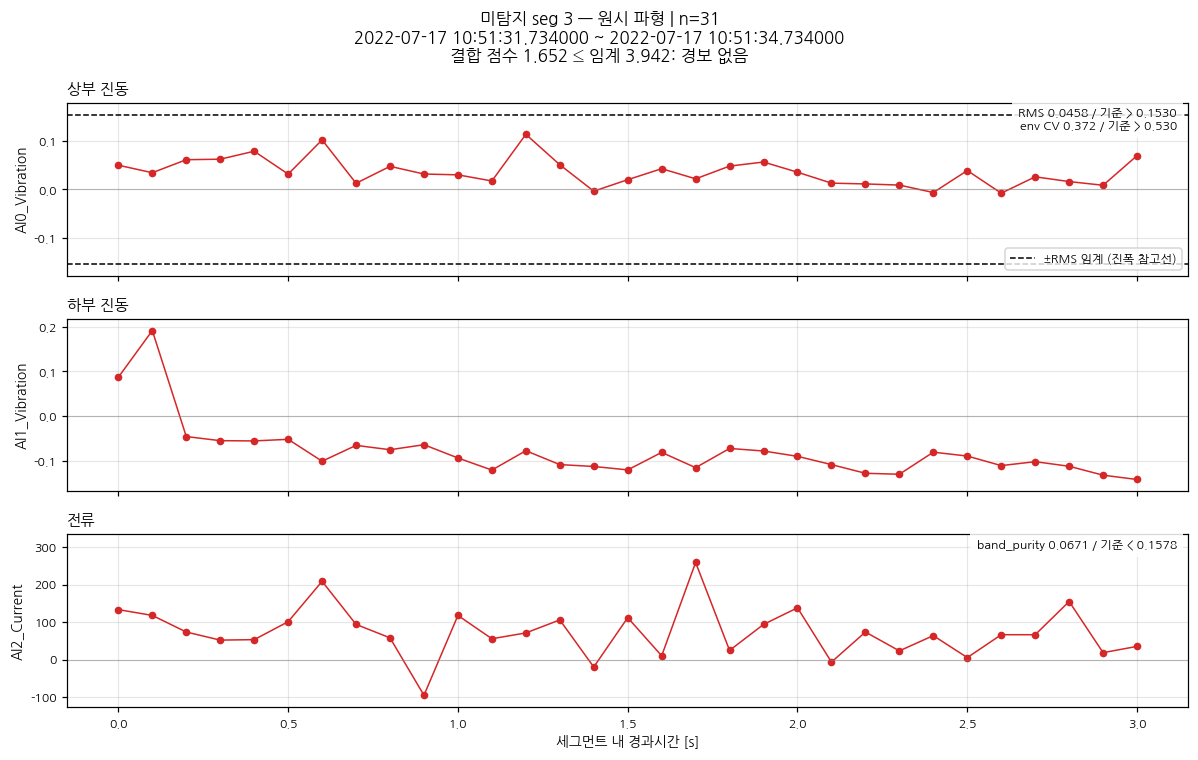

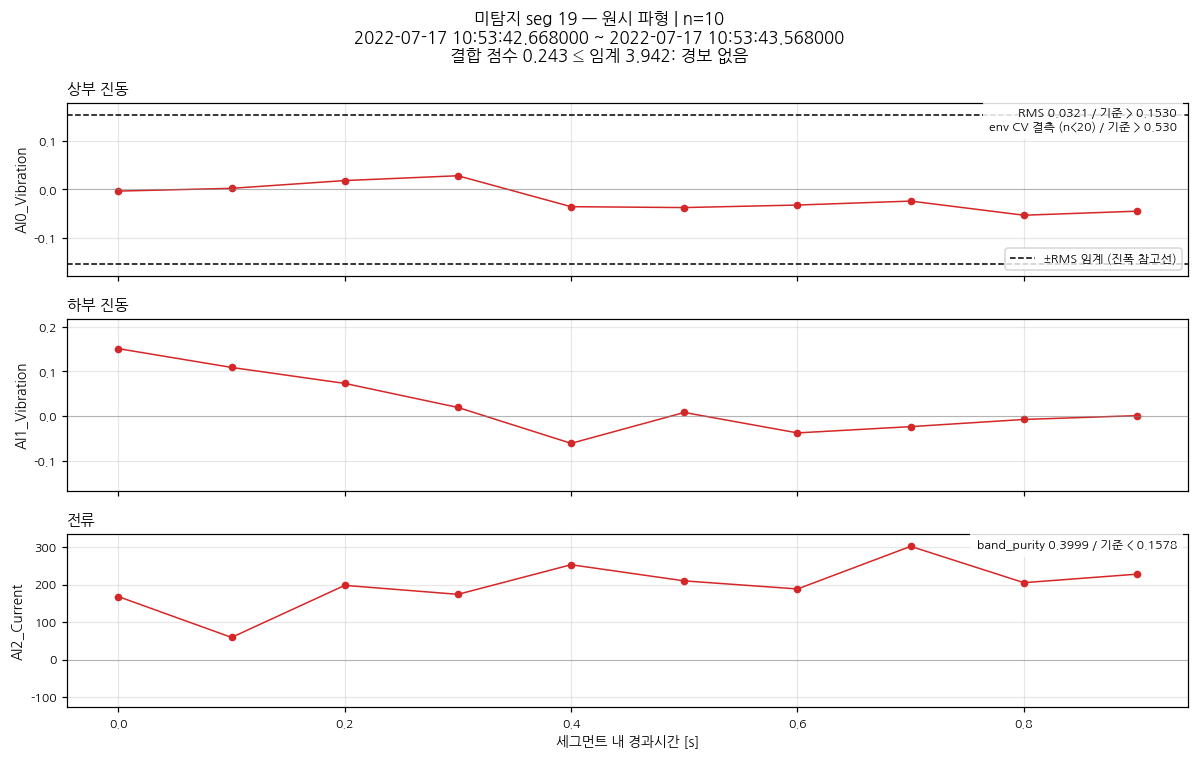

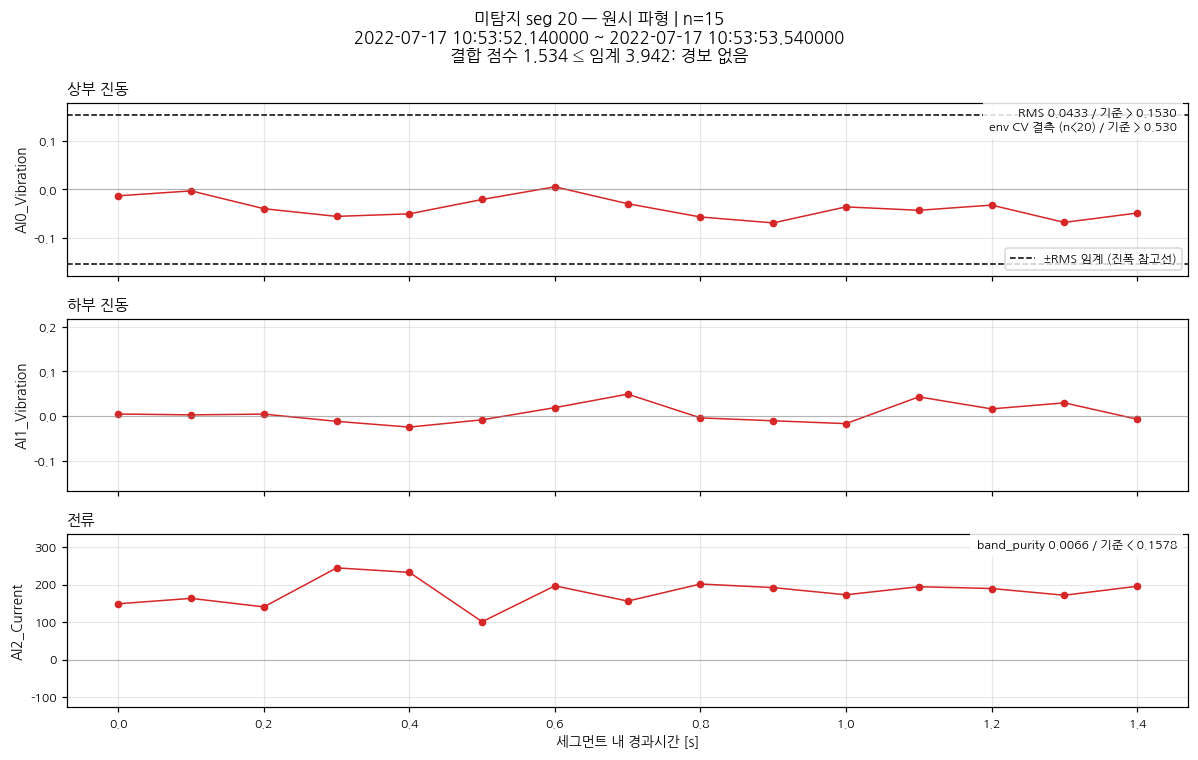

In [9]:
raw_channels = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
raw_names = ["상부 진동", "하부 진동", "전류"]
raw_ids = Fo.loc[Fo.score <= thr_combo, "seg_id"].tolist()
raw_segments = {sid: SEG["outlier"].loc[SEG["outlier"].seg_id == sid].copy()
                for sid in raw_ids}
rms_threshold = train.ai0_rms.max()
purity_threshold = train.purity.min()
env_threshold = train.env_cv.max()
raw_limits = {}
for channel in raw_channels:
    values = pd.concat([g[channel] for g in raw_segments.values()])
    lo, hi = values.min(), values.max()
    if channel == "AI0_Vibration":
        lo, hi = min(lo, -rms_threshold), max(hi, rms_threshold)
    pad = max((hi - lo) * .08, .001)
    raw_limits[channel] = (lo - pad, hi + pad)

for sid, g in raw_segments.items():
    features = Fo.loc[Fo.seg_id == sid].iloc[0]
    elapsed = (g.TimeStamp - g.TimeStamp.iloc[0]).dt.total_seconds()
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    for ax, channel, name in zip(axes, raw_channels, raw_names):
        ax.plot(elapsed, g[channel], "o-", color=COLOR["outlier"], lw=1, ms=4)
        ax.axhline(0, color="gray", lw=.7, alpha=.5)
        ax.set_ylim(*raw_limits[channel])
        ax.set_ylabel(channel)
        ax.set_title(name, loc="left")
    for sign in [-1, 1]:
        axes[0].axhline(sign * rms_threshold, color="black", ls="--", lw=1,
                        label="±RMS 임계 (진폭 참고선)" if sign == 1 else None)
    env_value = f"{features.env_cv:.3f}" if pd.notna(features.env_cv) else "결측 (n<20)"
    axes[0].text(.99, .97,
                 f"RMS {features.ai0_rms:.4f} / 기준 > {rms_threshold:.4f}\n"
                 f"env CV {env_value} / 기준 > {env_threshold:.3f}",
                 transform=axes[0].transAxes, ha="right", va="top", fontsize=8,
                 bbox=dict(facecolor="white", alpha=.85, edgecolor="none"))
    axes[0].legend(loc="lower right", fontsize=8)
    axes[2].text(.99, .97,
                 f"band_purity {features.purity:.4f} / 기준 < {purity_threshold:.4f}",
                 transform=axes[2].transAxes, ha="right", va="top", fontsize=8,
                 bbox=dict(facecolor="white", alpha=.85, edgecolor="none"))
    axes[-1].set_xlabel("세그먼트 내 경과시간 [s]")
    fig.suptitle(f"미탐지 seg {sid} — 원시 파형 | n={len(g)}\n"
                 f"{g.TimeStamp.iloc[0]} ~ {g.TimeStamp.iloc[-1]}\n"
                 f"결합 점수 {features.score:.3f} ≤ 임계 {thr_combo:.3f}: 경보 없음", fontsize=11)
    plt.tight_layout(); plt.show()


> **이하 내용은 기존 n≥10 실행의 기록입니다.** 전체 길이 포함 결과는 위 코드의 재실행 출력과 마지막 길이별 평가를 기준으로 읽습니다. 기존 미탐지를 원리적 한계로 확정하지 않습니다.

## 4. 정리 및 04로 넘길 것

### 확인된 사실

| # | 항목 | 결과 |
|---|---|---|
| 1 | 정상 내부 오경보율(최우선) | **0~0.6%** (V자 딥 구간 포함 test셋 기준). 우려했던 드리프트발 오경보는 기우였음 |
| 2 | 결합 점수 성능 | test 오경보 0%, outlier 14/17 탐지, AUC 0.979 |
| 3 | 미탐지 3개 재확인 | seg 3·19·20 — 3가지 독립 방법(01 임계/02 tier/03 결합점수) 전부 동일 → 원리적 하한으로 확정 |

### 04(모델링)로 넘길 설계 결정

1. **결합 점수(rms + purity + env_cv, z-score 평균)를 기본 이상도 점수로 채택.** 단순
   평균이라 튜닝 여지가 있지만(가중치, 로버스트 통계 등), 이미 test 오경보 0%·탐지
   14/17로 베이스라인은 확실하다.
2. **"N 중 M회" 지속성 규칙은 04에서 별도 검증이 필요하다.** 이 노트북에서는 시도하지
   않았다 — outlier가 21개 원본 세그먼트·2.8분뿐이라, 지속성 윈도우(N, M)를 이 데이터
   안에서 튜닝하면 그 자체로 과적합될 위험이 크다. 04에서는 04-1(부트스트랩/교차검증)과
   함께 다뤄야 한다.
3. **베이스라인은 rolling/EWMA로 전환할지 재검토.** 이번 정적(앞70%/뒤30%) 분할에서
   이미 오경보 0%가 나왔기 때문에, 01·02에서 예상했던 것만큼 rolling 기준선이 필수는
   아닐 수 있다. 다만 이건 "77분짜리 데이터 안에서"의 결론이라, 더 긴 운전 기간에서도
   유지되는지는 실제 운영 데이터로 확인이 필요하다.
4. **미탐지 3개는 모델 성능 한계가 아니라 하한으로 보고한다.** 04의 평가 프로토콜에서
   "17개 중 14개(82%) + 이 3개는 신호 자체가 정상 범위 안이라 원리적 미탐지"로 명시.
5. **평가 신뢰구간.** outlier가 17개뿐이라 82%(14/17)라는 점추정은 불안정하다.
   부트스트랩으로 신뢰구간을 붙여 보고한다.

## 5. 전체 세그먼트 길이별 오경보·미탐 평가

앞의 정상 시간순 70%/30% 분할과 train에서 정한 임계를 그대로 사용한다.
정상 오경보율은 **미사용 정상 test**에서, 미탐률은 **outlier 파일 전체**에서 계산한다.
각 길이 구간의 임계를 다시 맞추지 않아 길이에 따른 현재 로직의 차이를 비교할 수 있다.
`<5`, `5~9`, `10~14`, `15~19`, `20~29`, `30 이상`으로 나누고 `<20`/`≥20` 집계도 표시한다.

`purity`는 FFT 탐색 대역이 없거나 에너지가 0이면 결측, `env_cv`는 n<20이면 결측이다.
결측을 정상값 0으로 채우지 않으며 결합 점수는 유효 피처만 평균한다.
오경보율=FP/평가 가능한 정상, 미탐률=FN/평가 가능한 outlier이고, 판정 불가 건수를 별도로 표시한다.
파일 라벨을 세그먼트에 적용한 수치이므로 실제 세그먼트 정답 기준 오류율과는 다를 수 있다.
짧은 길이가 오류 원인인지 판단할 근거이며 인과관계를 확정하는 분석은 아니다.


결합 점수 — 길이별 결과 (비율과 함께 분모를 확인)
개별 피처 — 길이별 결과
결합 점수 오류 세그먼트


,길이,피처,정상 test 전체,정상 평가가능,정상 판정불가,FP,오경보율(%),outlier 전체,outlier 평가가능,outlier 판정불가,FN,미탐률(%)
0,<5,score,4,4,0,0,0.0,3,3,0,0,0.00
1,5~9,score,11,11,0,0,0.0,1,1,0,0,0.00
2,10~14,score,19,19,0,0,0.0,1,1,0,1,100.00
3,15~19,score,7,7,0,0,0.0,3,3,0,1,33.33
4,20~29,score,28,28,0,0,0.0,3,3,0,0,0.00
5,≥30,score,111,111,0,0,0.0,10,10,0,1,10.00
6,전체 <20,score,41,41,0,0,0.0,8,8,0,2,25.00
7,전체 ≥20,score,139,139,0,0,0.0,13,13,0,1,7.69


,길이,피처,정상 test 전체,정상 평가가능,정상 판정불가,FP,오경보율(%),outlier 전체,outlier 평가가능,outlier 판정불가,FN,미탐률(%)
0,<5,ai0_rms,4,4,0,0,0.00,3,3,0,0,0.00
1,<5,purity,4,0,4,0,NaN,3,0,3,0,NaN
2,<5,env_cv,4,0,4,0,NaN,3,0,3,0,NaN
3,<5,ai0_ac1,4,2,2,1,50.00,3,2,1,1,50.00
4,5~9,ai0_rms,11,11,0,0,0.00,1,1,0,0,0.00
5,5~9,purity,11,0,11,0,NaN,1,0,1,0,NaN
6,5~9,env_cv,11,0,11,0,NaN,1,0,1,0,NaN
7,5~9,ai0_ac1,11,11,0,0,0.00,1,1,0,1,100.00
8,10~14,ai0_rms,19,19,0,0,0.00,1,1,0,1,100.00
9,10~14,purity,19,19,0,0,0.00,1,1,0,1,100.00


,오류,label,seg_id,n,ai0_rms,purity,env_cv,score
3,FN,outlier,3,31,0.0458,0.0671,0.3715,1.6522
19,FN,outlier,19,10,0.0321,0.3999,NaN,0.2430
20,FN,outlier,20,15,0.0433,0.0066,NaN,1.5343


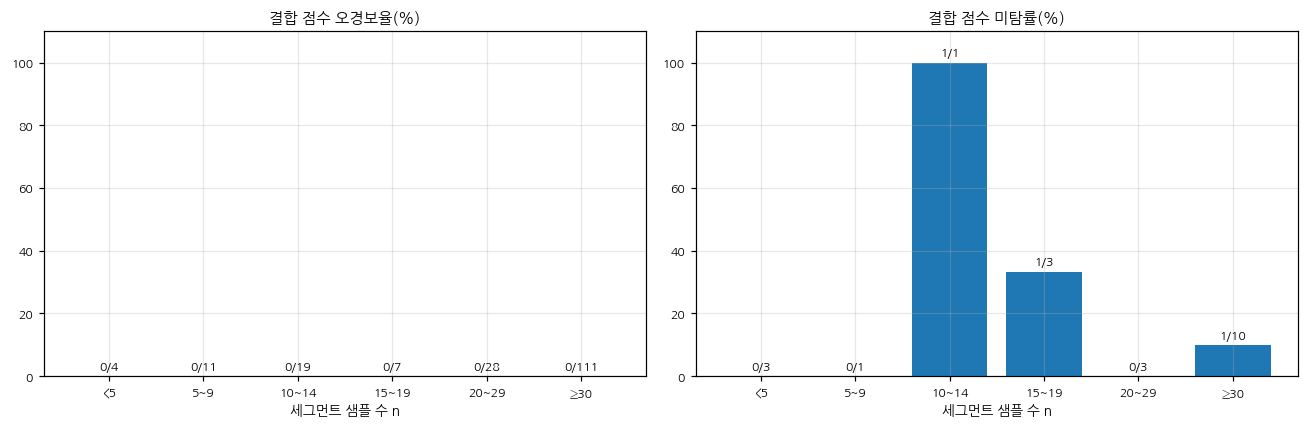

In [10]:
length_specs = [("<5", 1, 5), ("5~9", 5, 10), ("10~14", 10, 15),
                ("15~19", 15, 20), ("20~29", 20, 30), ("≥30", 30, np.inf),
                ("전체 <20", 1, 20), ("전체 ≥20", 20, np.inf)]
length_rows = []
for name, lower, upper in length_specs:
    normal_bin = test[(test.n >= lower) & (test.n < upper)]
    outlier_bin = Fo[(Fo.n >= lower) & (Fo.n < upper)]
    for feat, direction in list(FEATS.items()) + [("score", ">")]:
        threshold = thr_combo if feat == "score" else (
            train[feat].max() if direction == ">" else train[feat].min())
        normal_valid = normal_bin[feat].notna() & np.isfinite(normal_bin[feat])
        outlier_valid = outlier_bin[feat].notna() & np.isfinite(outlier_bin[feat])
        if pd.isna(threshold):
            normal_valid[:] = False
            outlier_valid[:] = False
        nv, ov = int(normal_valid.sum()), int(outlier_valid.sum())
        normal_alarm = normal_bin.loc[normal_valid, feat] > threshold if direction == ">" else normal_bin.loc[normal_valid, feat] < threshold
        outlier_alarm = outlier_bin.loc[outlier_valid, feat] > threshold if direction == ">" else outlier_bin.loc[outlier_valid, feat] < threshold
        fp_count, fn_count = int(normal_alarm.sum()), int((~outlier_alarm).sum())
        length_rows.append({"길이": name, "피처": feat, "정상 test 전체": len(normal_bin),
                           "정상 평가가능": nv, "정상 판정불가": len(normal_bin)-nv,
                           "FP": fp_count, "오경보율(%)": 100*fp_count/nv if nv else np.nan,
                           "outlier 전체": len(outlier_bin), "outlier 평가가능": ov,
                           "outlier 판정불가": len(outlier_bin)-ov,
                           "FN": fn_count, "미탐률(%)": 100*fn_count/ov if ov else np.nan})
length_metrics = pd.DataFrame(length_rows)
print("결합 점수 — 길이별 결과 (비율과 함께 분모를 확인)")
display(length_metrics[length_metrics.피처 == "score"].round(2).reset_index(drop=True))
print("개별 피처 — 길이별 결과")
display(length_metrics[length_metrics.피처 != "score"].round(2).reset_index(drop=True))
print("결합 점수 오류 세그먼트")
display(pd.concat([test.loc[test.score > thr_combo].assign(오류="FP"),
                   Fo.loc[Fo.score <= thr_combo].assign(오류="FN")])[
    ["오류", "label", "seg_id", "n", "ai0_rms", "purity", "env_cv", "score"]].round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
combo_lengths = length_metrics[(length_metrics.피처 == "score") & ~length_metrics.길이.str.startswith("전체")]
for ax, metric, denominator, count in [(axes[0], "오경보율(%)", "정상 평가가능", "FP"),
                                      (axes[1], "미탐률(%)", "outlier 평가가능", "FN")]:
    ax.bar(combo_lengths.길이, combo_lengths[metric])
    for j, row in enumerate(combo_lengths.to_dict("records")):
        value = row[metric]
        ax.text(j, value + 2 if pd.notna(value) else 2,
                f"{row[count]}/{row[denominator]}" if row[denominator] else "평가 없음",
                ha="center", fontsize=8)
    ax.set_ylim(0, 110)
    ax.set_title(f"결합 점수 {metric}")
    ax.set_xlabel("세그먼트 샘플 수 n")
plt.tight_layout(); plt.show()


### 전체 길이 포함 실행 결과

정상 599개를 시간순 train 419개 / test 180개로 나누고, outlier 21개 전체를 평가했다.
결합 점수는 정상 test **FP 0/180**, outlier **FN 3/21**이다.

| 길이 | 정상 test FP / 평가 건수 | outlier FN / 평가 건수 | 미탐률 |
|---|---|---|---|
| n < 20 | 0/41 (0%) | 2/8 | 25% |
| n ≥ 20 | 0/139 (0%) | 1/13 | 7.69% |

짧은 쪽에서 미탐률이 높지만 오경보 증가가 관측되지는 않았다.
특히 n<5에서는 전류 FFT 탐색 대역이 없어 purity가 결측이며, n<20에서는 env_cv가 결측이다.
따라서 결합 점수의 사용 피처 수가 길이에 따라 달라진다는 점도 함께 해석해야 한다.
이상 표본이 적고 라벨이 파일 단위이므로 길이의 인과 효과나 세그먼트별 실제 오류를 확정할 수 없다.
또한 전체 길이를 포함하면서 train 분포와 임계도 다시 계산했으므로 기존 n≥10 결과와의 차이를
길이 추가 효과만으로 해석하지 않는다. 정상 오경보 0건 역시 실제 운영 오경보율이 0임을 보장하지 않는다.
